In [1]:
import numpy as np
import os
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

### 資料集讀取
- Mnist資料是影像資料：(28,28,1)的灰階圖

In [2]:
from sklearn.datasets import fetch_openml

# fetch_mldata 已在新版 scikit-learn 移除，改用 OpenML 載入 MNIST
mnist_openml = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
mnist = {
    'data': mnist_openml['data'],
    'target': mnist_openml['target'].astype(float),
    'DESCR': 'OpenML dataset: mnist_784',
    'COL_NAMES': ['label', 'data'],
}
mnist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'target': array([5., 0., 4., ..., 4., 5., 6.]),
 'DESCR': 'OpenML dataset: mnist_784',
 'COL_NAMES': ['label', 'data']}

In [3]:
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

In [4]:
y.shape

(70000,)

![title](./img/9.png)

In [5]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [6]:
# 洗牌操作
import numpy as np

shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]

In [7]:
shuffle_index

array([12628, 37730, 39991, ...,   860, 15795, 56422])

### 交叉驗證

![title](./img/5.png)

![title](./img/7.png)

In [8]:
y_train_5 = (y_train==5)
y_test_5 = (y_test==5)

In [9]:
y_train_5[:10]

array([False, False, False, False, False, False, False, False,  True,
       False])

In [10]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(max_iter=5,random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(max_iter=5, random_state=42)

In [11]:
sgd_clf.predict([X[35000]])

array([False])

In [12]:
y[35000]

np.float64(1.0)

In [13]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.964 , 0.9579, 0.9571])

In [14]:
X_train.shape

(60000, 784)

In [15]:
y_train_5.shape

(60000,)

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skflods = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for train_index,test_index in skflods.split(X_train,y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train_5[test_index]
    
    clone_clf.fit(X_train_folds,y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct/len(y_pred))

0.963
0.9455


0.95255


### Confusion Matrix-混淆矩陣

![title](./img/8.png)

In [17]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)

In [18]:
y_train_pred.shape

(60000,)

In [19]:
X_train.shape

(60000, 784)

In [20]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[54058,   521],
       [ 1899,  3522]])

negative class  [[ **true negatives** , **false positives** ],
 
positive class  [ **false negatives** , **true positives** ]]

* true negatives: 53,272個資料被正確的分為非5類別
* false positives：1307張被錯誤的分為5類別

* false negatives：1077張錯誤的分為非5類別
* true positives： 4344 張被正確的分為5個類別

一個完美的分類器應該只有**true positives** 和 **true negatives**, 即主對角線元素不為0，其餘元素為0

### Precision and Recall


### **$ precision = \frac {TP} {TP + FP} $**


### **$ recall = \frac {TP} {TP + FN} $**

![title](./img/1.png)

In [21]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5,y_train_pred)

0.8711352955725946

In [22]:
recall_score(y_train_5,y_train_pred)

0.6496956281128943

將**Precision** 和 **Recall**結合到一個稱為**F1 score** 的指標,調和平均值給予低值更多權重。 因此，如果召回和精確度都很高，分類器將獲得高F 1分數。

### $ F_1  = $ $2\over {1\over precision}+{1\over recall} $ $=$ $2×$ $precision×recall\over precision+recall $ $=$ $TP\over {TP}+{FN + FP\over 2}$

In [23]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7442941673710904

### 閾值對結果的影響

![title](./img/2.png)

In [24]:
y_scores = sgd_clf.decision_function([X[35000]])
y_scores

array([-232764.96231592])

In [25]:
t = 50000
y_pred = (y_scores > t)
y_pred

array([False])

Scikit-Learn不允許直接設定閾值，但它可以得到決策分數，呼叫其**decision_function（）**方法，而不是呼叫分類器的**predict（）**方法，該方法傳回每個實例的分數，然後使用想要的**閾值**根據這些分數進行預測：

In [26]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

In [27]:
y_scores[:10]

array([ -545086.1906455 ,  -200238.20632717,  -366873.76172794,
        -648828.94558457,  -572767.52239341, -1016184.25580999,
        -419438.40135301,  -171080.39957192,   237230.03978349,
        -793932.50331371])

In [28]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [29]:
y_train_5.shape

(60000,)

In [30]:
thresholds.shape

(59999,)

In [31]:
precisions[:10]

array([0.09035   , 0.09035151, 0.09035301, 0.09035452, 0.09035602,
       0.09035753, 0.09035904, 0.09036054, 0.09036205, 0.09036355])

In [32]:
precisions.shape

(60000,)

In [33]:
recalls.shape

(60000,)

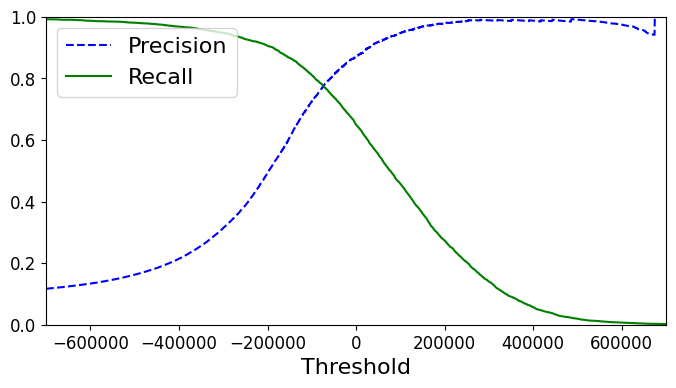

In [34]:
def plot_precision_recall_vs_threshold(precisions,recalls,thresholds):
    plt.plot(thresholds,
             precisions[:-1],
            "b--",
            label="Precision")
    
    plt.plot(thresholds,
             recalls[:-1],
            "g-",
            label="Recall")
    plt.xlabel("Threshold",fontsize=16)
    plt.legend(loc="upper left",fontsize=16)
    plt.ylim([0,1])
    
plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions,recalls,thresholds)
plt.xlim([-700000, 700000])
plt.show()

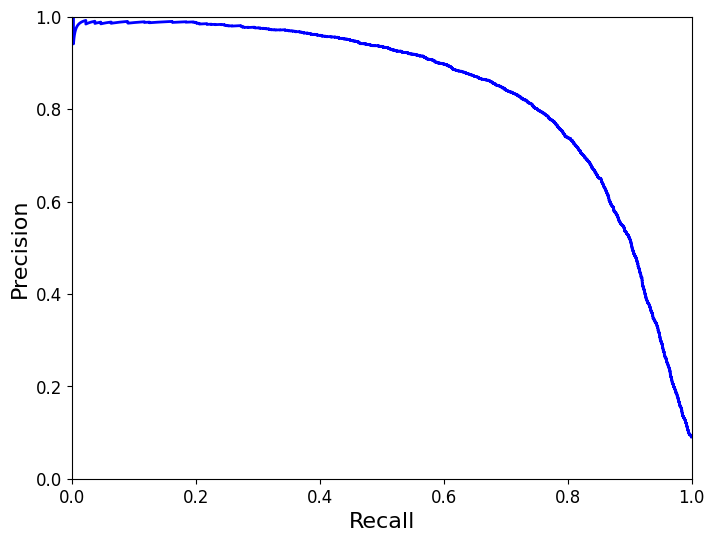

In [35]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, 
             precisions, 
             "b-", 
             linewidth=2)
    
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.show()

### ROC curves
**receiver operating characteristic (ROC)** 曲線是二元分類中的常用評估方法
* 它與精確度/召回曲線非常相似，但ROC曲線不是繪製精確度與召回率，而是繪製**true positive rate(TPR)** 與**false positive rate(FPR)**

* 要繪製ROC曲線，首先需要使用**roc_curve（）**函數計算各種閾值的**TPR和FPR**：

TPR = TP / (TP + FN) (Recall)

FPR = FP / (FP + TN)

In [36]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

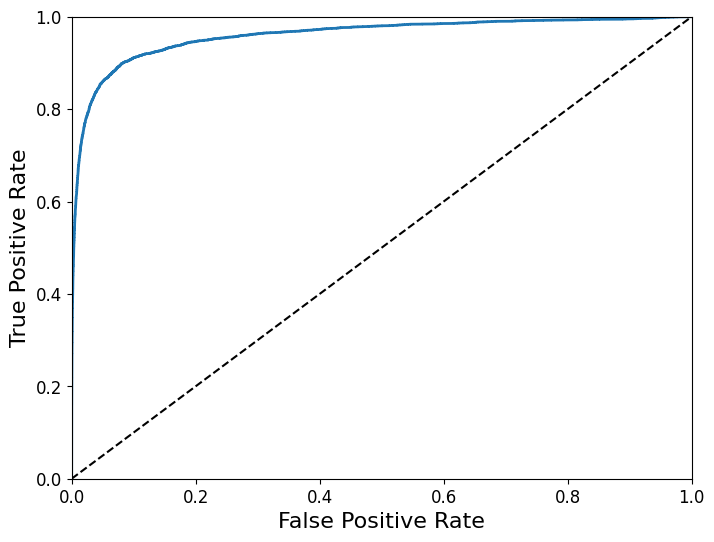

In [37]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

**虛線表示純隨機分類器的ROC曲線**; 一個好的分類器盡可能遠離該線（朝左上角）。

比較分類器的一種方法是測量曲線下面積（AUC）。完美分類器的ROC AUC**等於1**，而純隨機分類器的ROC AUC**等於0.5**。 Scikit-Learn提供了計算ROC AUC的函數：

In [38]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

np.float64(0.9598058535696421)